In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('outputs', exist_ok=True)

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid")

CHANNEL_COLORS = {
    'Paid Ads'    : '#2563EB',
    'Social Media': '#7C3AED',
    'Email'       : '#059669',
    'SEO'         : '#D97706',
    'Referral'    : '#DC2626'
}
print("✅ Setup complete")

✅ Setup complete


In [3]:
df = pd.read_csv('funnel_data.csv', parse_dates=['date'])

df['month']           = df['date'].dt.to_period('M')
df['month_no']        = df['date'].dt.month
df['lead_to_customer'] = df['customers'] / df['leads'] * 100
df['cost_per_lead']   = df['cost'] / df['leads']
df['cost_per_customer'] = df['cost'] / df['customers']
df['roi']             = (df['revenue'] - df['cost']) / df['cost'] * 100

print(f"Total records   : {len(df)}")
print(f"Date range      : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Channels        : {df['channel'].unique()}")
print(f"Total leads     : {df['leads'].sum():,}")
print(f"Total customers : {df['customers'].sum():,}")
df.head()

Total records   : 60
Date range      : 2024-01-05 → 2024-12-25
Channels        : ['Social Media' 'Email' 'SEO' 'Paid Ads' 'Referral']
Total leads     : 29,445
Total customers : 2,493


,lead_id,date,channel,campaign,country,age_group,device,leads,prospects,MQL,...,opportunities,customers,revenue,cost,month,month_no,lead_to_customer,cost_per_lead,cost_per_customer,roi
0,L001,2024-01-05,Social Media,Brand Awareness,India,18-24,Mobile,500,320,180,...,60,35,52500,8000,2024-01,1,7.000000,16.000000,228.571429,556.25
1,L002,2024-01-10,Email,Newsletter,USA,25-34,Desktop,300,210,150,...,55,40,72000,5000,2024-01,1,13.333333,16.666667,125.000000,1340.00
2,L003,2024-01-15,SEO,Organic,UK,35-44,Desktop,400,280,160,...,50,30,54000,3000,2024-01,1,7.500000,7.500000,100.000000,1700.00
3,L004,2024-01-20,Paid Ads,Google Ads,India,25-34,Mobile,600,380,200,...,70,45,81000,12000,2024-01,1,7.500000,20.000000,266.666667,575.00
4,L005,2024-01-25,Referral,Partner,USA,45-54,Desktop,150,120,90,...,45,35,70000,2000,2024-01,1,23.333333,13.333333,57.142857,3400.00


In [4]:
total_leads     = df['leads'].sum()
total_customers = df['customers'].sum()
total_revenue   = df['revenue'].sum()
total_cost      = df['cost'].sum()
overall_conv    = total_customers / total_leads * 100
overall_roi     = (total_revenue - total_cost) / total_cost * 100
avg_cpl         = total_cost / total_leads
avg_cpc         = total_cost / total_customers

print("=" * 48)
print("     MARKETING FUNNEL KPI SUMMARY")
print("=" * 48)
print(f"  Total Leads          : {total_leads:,}")
print(f"  Total Customers      : {total_customers:,}")
print(f"  Overall Conv. Rate   : {overall_conv:.2f}%")
print(f"  Total Revenue        : ${total_revenue:,.0f}")
print(f"  Total Ad Spend       : ${total_cost:,.0f}")
print(f"  Overall ROI          : {overall_roi:.1f}%")
print(f"  Avg Cost Per Lead    : ${avg_cpl:.2f}")
print(f"  Avg Cost Per Customer: ${avg_cpc:.2f}")
print("=" * 48)

     MARKETING FUNNEL KPI SUMMARY
  Total Leads          : 29,445
  Total Customers      : 2,493
  Overall Conv. Rate   : 8.47%
  Total Revenue        : $4,434,600
  Total Ad Spend       : $446,200
  Overall ROI          : 893.9%
  Avg Cost Per Lead    : $15.15
  Avg Cost Per Customer: $178.98


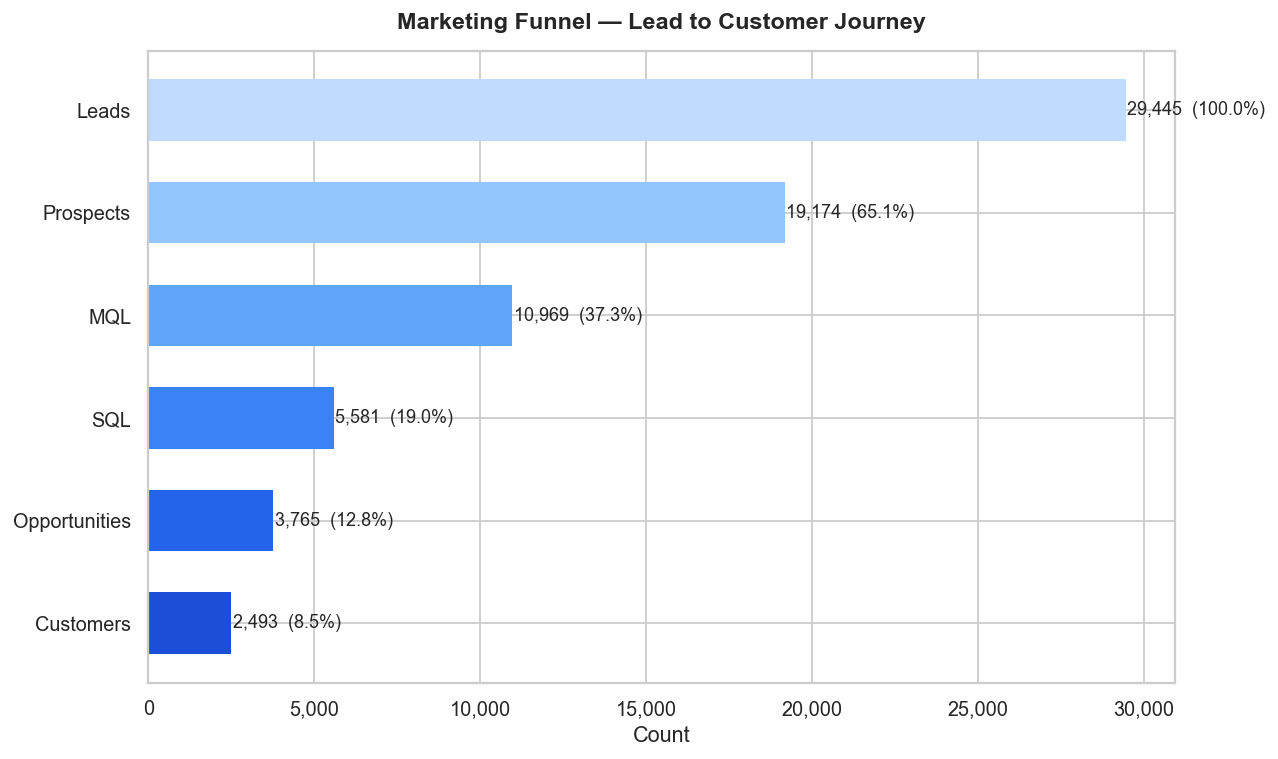

✅ Saved: 01_funnel_overview.png


In [5]:
stages = ['Leads', 'Prospects', 'MQL', 'SQL', 'Opportunities', 'Customers']
values = [df['leads'].sum(), df['prospects'].sum(), df['MQL'].sum(),
          df['SQL'].sum(), df['opportunities'].sum(), df['customers'].sum()]

drop_pcts = [100]
for i in range(1, len(values)):
    drop_pcts.append(values[i] / values[0] * 100)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1D4ED8','#2563EB','#3B82F6','#60A5FA','#93C5FD','#BFDBFE']
bars = ax.barh(stages[::-1], values[::-1],
               color=colors, edgecolor='none', height=0.6)

for bar, val, pct in zip(bars, values[::-1], drop_pcts[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f"{val:,}  ({pct:.1f}%)", va='center', fontsize=10)

ax.set_title("Marketing Funnel — Lead to Customer Journey",
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig('outputs/01_funnel_overview.png', bbox_inches='tight')
plt.show()
print("✅ Saved: 01_funnel_overview.png")

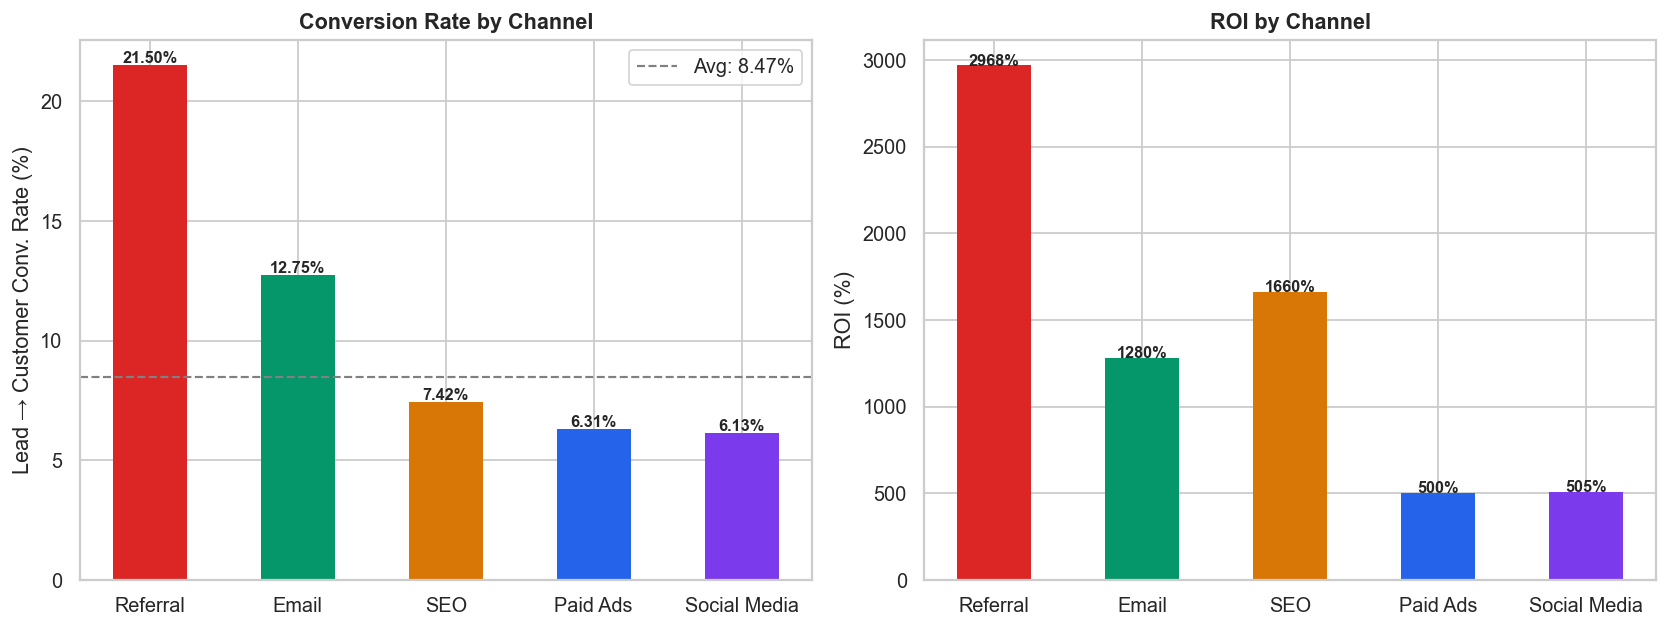

✅ Saved: 02_channel_performance.png


In [6]:
ch = df.groupby('channel').agg(
    Leads=('leads','sum'),
    Customers=('customers','sum'),
    Revenue=('revenue','sum'),
    Cost=('cost','sum')
).reset_index()
ch['conv_rate'] = ch['Customers'] / ch['Leads'] * 100
ch['roi']       = (ch['Revenue'] - ch['Cost']) / ch['Cost'] * 100
ch = ch.sort_values('conv_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Conversion rate
bars = axes[0].bar(ch['channel'], ch['conv_rate'],
                   color=[CHANNEL_COLORS[c] for c in ch['channel']],
                   width=0.5, edgecolor='none')
for bar, val in zip(bars, ch['conv_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.1,
                 f"{val:.2f}%", ha='center', fontsize=9, fontweight='bold')
axes[0].axhline(overall_conv, color='gray', linestyle='--', linewidth=1.2,
                label=f'Avg: {overall_conv:.2f}%')
axes[0].set_title("Conversion Rate by Channel", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Lead → Customer Conv. Rate (%)")
axes[0].legend()

# ROI by channel
bars2 = axes[1].bar(ch['channel'], ch['roi'],
                    color=[CHANNEL_COLORS[c] for c in ch['channel']],
                    width=0.5, edgecolor='none')
for bar, val in zip(bars2, ch['roi']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f"{val:.0f}%", ha='center', fontsize=9, fontweight='bold')
axes[1].set_title("ROI by Channel", fontsize=12, fontweight='bold')
axes[1].set_ylabel("ROI (%)")

plt.tight_layout()
plt.savefig('outputs/02_channel_performance.png', bbox_inches='tight')
plt.show()
print("✅ Saved: 02_channel_performance.png")

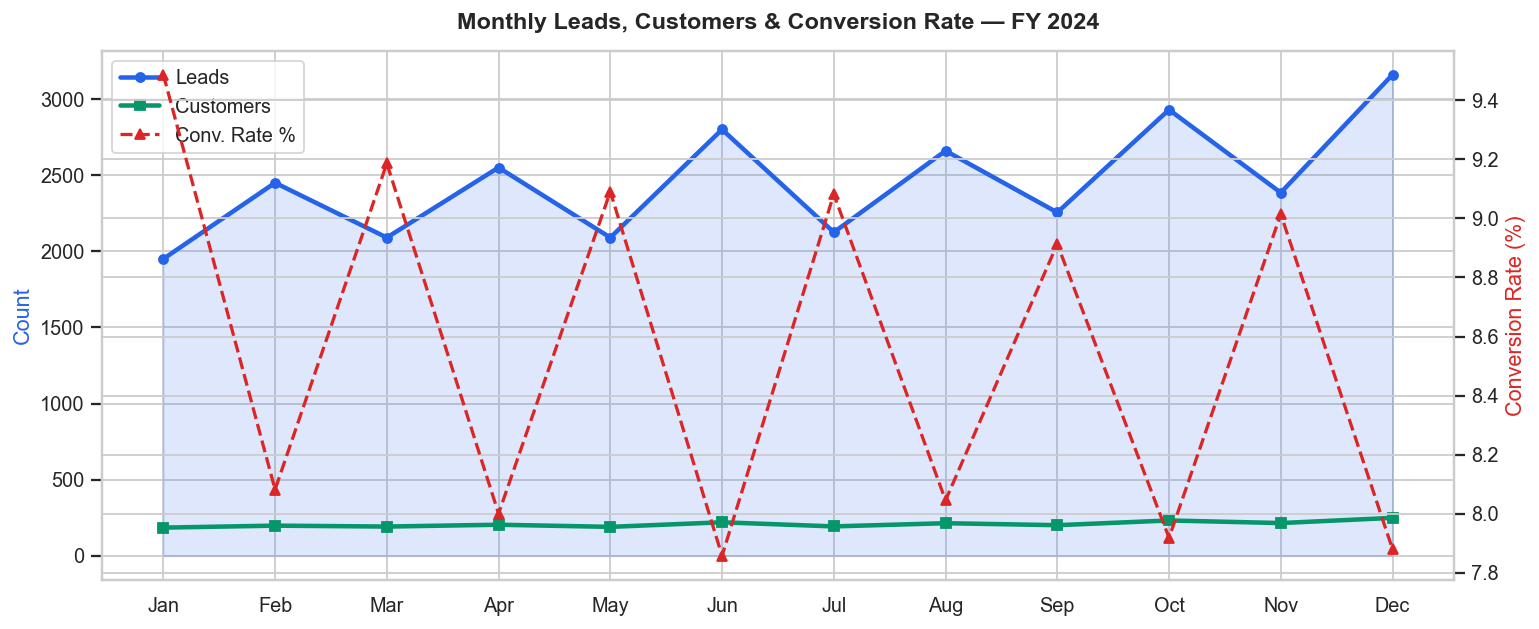

✅ Saved: 03_monthly_trend.png


In [7]:
monthly = df.groupby('month_no').agg(
    Leads=('leads','sum'),
    Customers=('customers','sum')
).reset_index()
monthly['conv_rate'] = monthly['Customers'] / monthly['Leads'] * 100
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.fill_between(monthly['month_no'], monthly['Leads'],
                 alpha=0.15, color='#2563EB')
ax1.plot(monthly['month_no'], monthly['Leads'],
         color='#2563EB', linewidth=2.5, marker='o', markersize=5, label='Leads')
ax1.plot(monthly['month_no'], monthly['Customers'],
         color='#059669', linewidth=2.5, marker='s', markersize=5, label='Customers')

ax2.plot(monthly['month_no'], monthly['conv_rate'],
         color='#DC2626', linewidth=1.8, linestyle='--', marker='^',
         markersize=5, label='Conv. Rate %')

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_labels)
ax1.set_ylabel("Count", color='#2563EB')
ax2.set_ylabel("Conversion Rate (%)", color='#DC2626')
ax1.set_title("Monthly Leads, Customers & Conversion Rate — FY 2024",
              fontsize=13, fontweight='bold', pad=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig('outputs/03_monthly_trend.png', bbox_inches='tight')
plt.show()
print("✅ Saved: 03_monthly_trend.png")

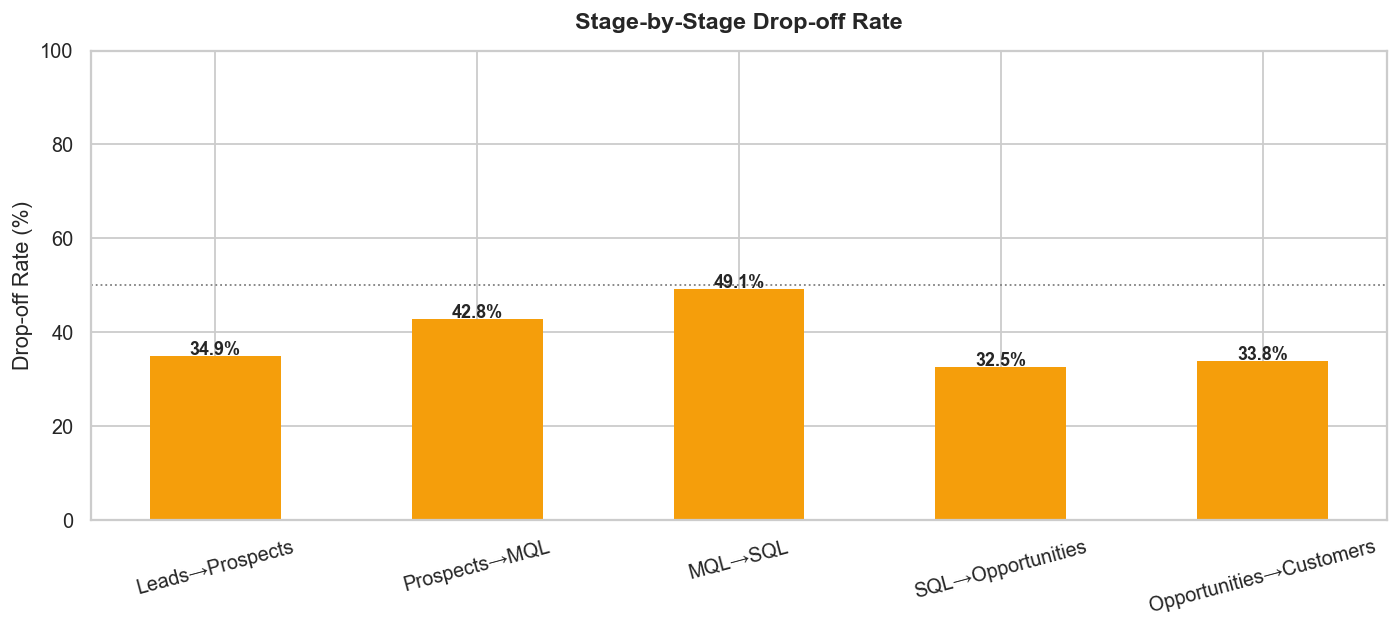

✅ Saved: 04_dropoff_analysis.png


In [8]:
stages = ['Leads','Prospects','MQL','SQL','Opportunities','Customers']
vals   = [df['leads'].sum(), df['prospects'].sum(), df['MQL'].sum(),
          df['SQL'].sum(), df['opportunities'].sum(), df['customers'].sum()]

dropoffs = []
for i in range(1, len(vals)):
    dropoffs.append((vals[i-1] - vals[i]) / vals[i-1] * 100)

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#DC2626' if d > 50 else '#F59E0B' if d > 30 else '#059669'
          for d in dropoffs]
bars = ax.bar(
    [f"{stages[i]}→{stages[i+1]}" for i in range(len(dropoffs))],
    dropoffs, color=colors, width=0.5, edgecolor='none'
)
for bar, val in zip(bars, dropoffs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            f"{val:.1f}%", ha='center', fontsize=10, fontweight='bold')

ax.set_title("Stage-by-Stage Drop-off Rate", fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel("Drop-off Rate (%)")
ax.set_ylim(0, 100)
ax.axhline(50, color='gray', linestyle=':', linewidth=1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('outputs/04_dropoff_analysis.png', bbox_inches='tight')
plt.show()
print("✅ Saved: 04_dropoff_analysis.png")

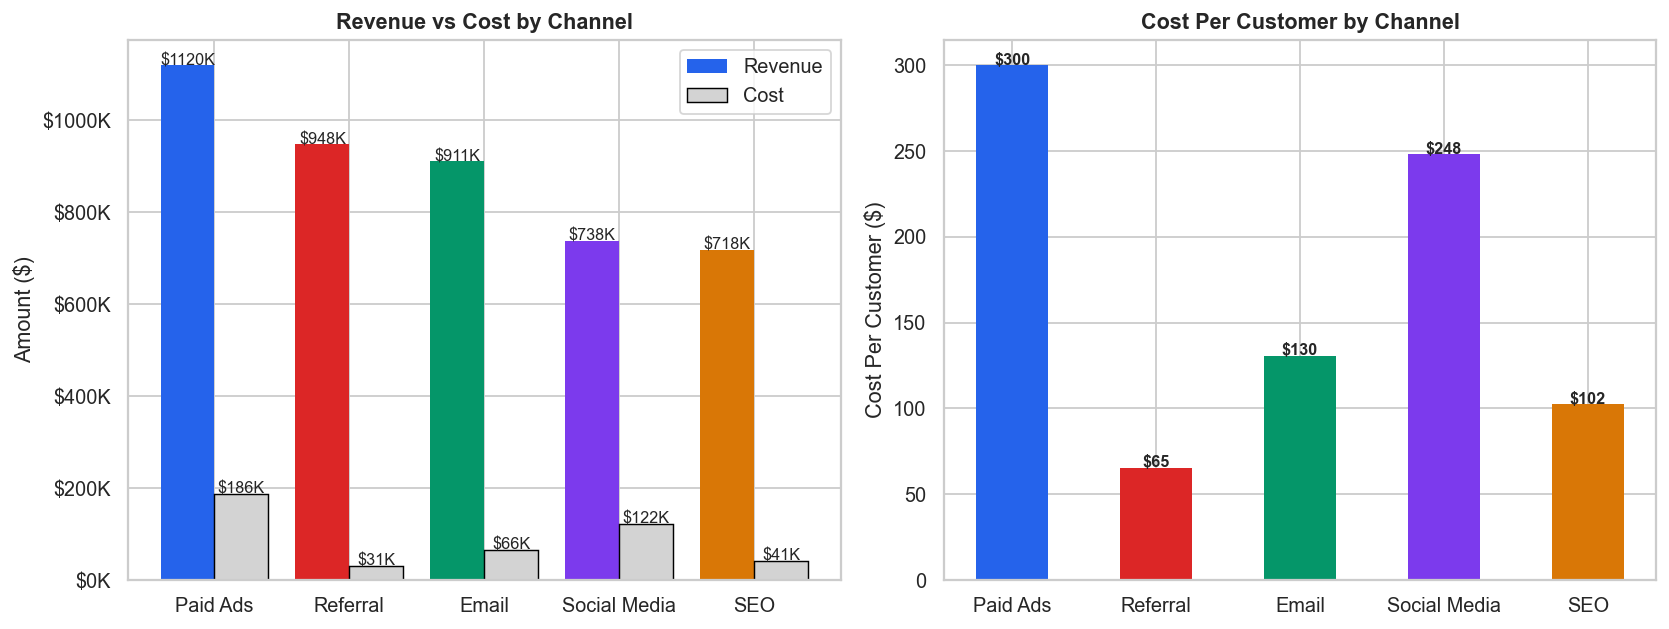

✅ Saved: 05_cost_revenue_channel.png


In [13]:
ch2 = df.groupby('channel').agg(
    Cost=('cost','sum'),
    Revenue=('revenue','sum'),
    Customers=('customers','sum')
).reset_index()
ch2['cpc'] = ch2['Cost'] / ch2['Customers']
ch2 = ch2.sort_values('Revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Revenue bars
x = np.arange(len(ch2['channel']))
width = 0.4

bars_rev = axes[0].bar(x - width/2, ch2['Revenue'],
                       width=width, color=[CHANNEL_COLORS[c] for c in ch2['channel']],
                       edgecolor='none', label='Revenue')
bars_cost = axes[0].bar(x + width/2, ch2['Cost'],
                        width=width, color='lightgray',
                        edgecolor='black', linewidth=0.8, label='Cost')

for bar, val in zip(bars_rev, ch2['Revenue']):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 1000,
                 f"${val/1000:.0f}K", ha='center', fontsize=9)
for bar, val in zip(bars_cost, ch2['Cost']):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 1000,
                 f"${val/1000:.0f}K", ha='center', fontsize=9)

axes[0].set_xticks(x)
axes[0].set_xticklabels(ch2['channel'])
axes[0].set_title("Revenue vs Cost by Channel", fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1000:.0f}K"))
axes[0].set_ylabel("Amount ($)")
axes[0].legend()

# Cost per customer
bars2 = axes[1].bar(ch2['channel'], ch2['cpc'],
                    color=[CHANNEL_COLORS[c] for c in ch2['channel']],
                    width=0.5, edgecolor='none')
for bar, val in zip(bars2, ch2['cpc']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f"${val:.0f}", ha='center', fontsize=9, fontweight='bold')
axes[1].set_title("Cost Per Customer by Channel", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Cost Per Customer ($)")

plt.tight_layout()
plt.savefig('outputs/05_cost_revenue_channel.png', bbox_inches='tight')
plt.show()
print("✅ Saved: 05_cost_revenue_channel.png")

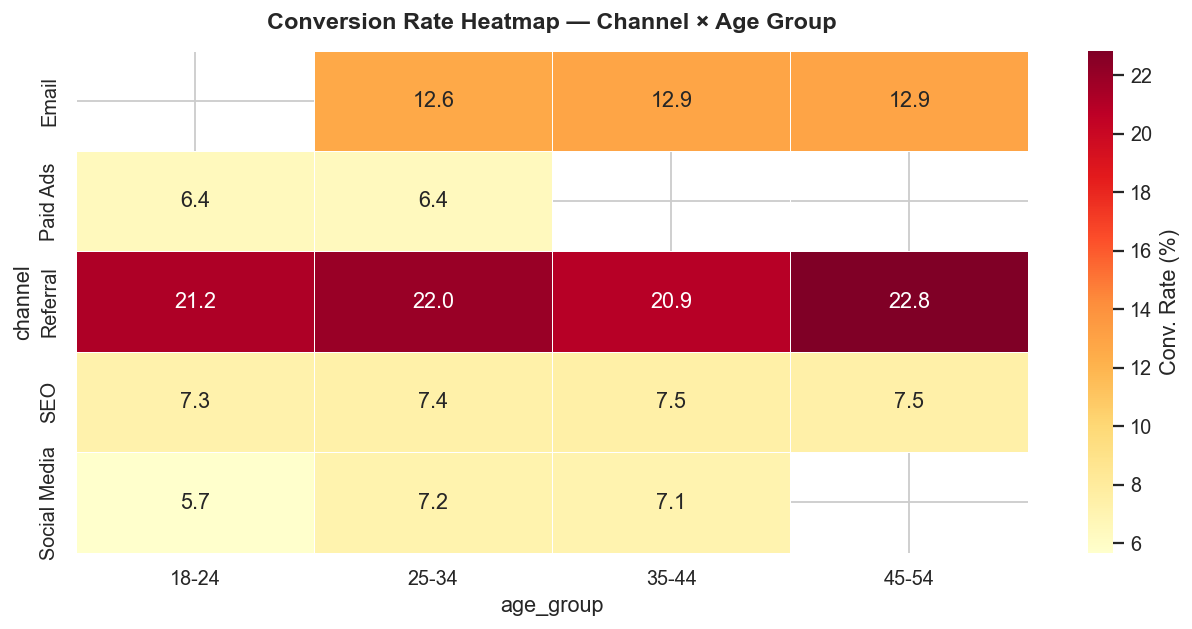

✅ Saved: 06_heatmap_channel_age.png


In [14]:
pivot = df.pivot_table(values='lead_to_customer',
                       index='channel', columns='age_group',
                       aggfunc='mean')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Conv. Rate (%)'})
ax.set_title("Conversion Rate Heatmap — Channel × Age Group",
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('outputs/06_heatmap_channel_age.png', bbox_inches='tight')
plt.show()
print("✅ Saved: 06_heatmap_channel_age.png")

In [15]:
summary = df.groupby('channel').agg(
    Total_Leads=('leads','sum'),
    Total_Customers=('customers','sum'),
    Conv_Rate=('lead_to_customer', lambda x: f"{x.mean():.2f}%"),
    Total_Revenue=('revenue', lambda x: f"${x.sum():,.0f}"),
    Total_Cost=('cost', lambda x: f"${x.sum():,.0f}"),
    ROI=('roi', lambda x: f"{x.mean():.1f}%"),
    Avg_CPL=('cost_per_lead', lambda x: f"${x.mean():.2f}"),
    Avg_CPC=('cost_per_customer', lambda x: f"${x.mean():.2f}")
)

print("\n📊 Channel Performance Summary\n")
print(summary.to_string())
summary.to_csv('outputs/funnel_summary.csv')
print("\n✅ Saved: funnel_summary.csv")


📊 Channel Performance Summary

              Total_Leads  Total_Customers Conv_Rate Total_Revenue Total_Cost      ROI Avg_CPL  Avg_CPC
channel                                                                                                
Email                3970              506    12.76%      $910,800    $66,000  1289.6%  $16.57  $129.98
Paid Ads             9860              622     6.40%    $1,119,600   $186,500   503.6%  $19.05  $298.95
Referral             2205              474    21.65%      $948,000    $30,900  3014.0%  $13.95   $64.73
SEO                  5380              399     7.42%      $718,200    $40,800  1664.6%   $7.58  $102.13
Social Media         8030              492     6.29%      $738,000   $122,000   513.6%  $15.33  $246.40

✅ Saved: funnel_summary.csv
